# Following the official PPO tutorial from TorchRL
Link: https://pytorch.org/tutorials/intermediate/reinforcement_ppo.html

In [9]:
import warnings
warnings.filterwarnings("ignore")
from torch import multiprocessing

from collections import defaultdict

import matplotlib.pyplot as plt
import torch
from tensordict import TensorDict
from tensordict.nn import TensorDictModule, TensorDictSequential
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torchrl import modules as trl_modules
from torchrl.envs.libs import register_gym_spec_conversion
from torchrl.collectors import SyncDataCollector, MultiaSyncDataCollector
from torchrl.data.tensor_specs import NonTensor
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (Compose, DoubleToFloat, ObservationNorm, StepCounter, TransformedEnv, DTypeCastTransform, BatchSizeTransform, CatFrames, ExcludeTransform, UnsqueezeTransform, Transform)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from functorch.experimental import replace_all_batch_norm_modules_
from tqdm import tqdm

from sentence_transformers import SentenceTransformer
from odyssey.nn.nethack.glyph_embedding import create_glyph_text_embedding
from odyssey.nn.nethack.map_embedding import MapEmbedding
from odyssey.nethack.transforms import render_tty_chars_transform

import os
import h5py
from omegaconf import OmegaConf

# Load trained CPC Model

In [10]:
import hydra
from odyssey.lightning.models.cpc import CPCModel
from odyssey.nn.nethack.tty_encoder import ResnetTTYEncoder
from odyssey.nn.contrastive.context_transformer import ContextTransformer

logdir = "/workspace/logs/train_cpc/runs/2025-06-08_16-31-09"
chkpt_name = "last-v3.ckpt"
data_path = "/workspace/data/nld_nao_test.h5"
device = "cuda" if torch.cuda.is_available() else "cpu"

config_path = os.path.join(logdir, ".hydra", "config.yaml")
config = OmegaConf.load(config_path)
chkpt = torch.load(os.path.join(logdir, "checkpoints", chkpt_name))
data = h5py.File("/workspace/data/nld_nao_train.h5", "r")

lightning_model: CPCModel = hydra.utils.instantiate(config.model)
lightning_model.load_state_dict(chkpt["state_dict"])
lightning_model = lightning_model.to(device)
lightning_model.freeze()

tty_embedding: ResnetTTYEncoder = lightning_model.tty_embedding
# replace_all_batch_norm_modules_(tty_embedding.resnet)
context_embedding: ContextTransformer = lightning_model.context_embedding
future_obs_predictor = lightning_model.future_obs_predictor
future_length = config.future_length
context_length = config.context_length

# Hyperparameters

In [11]:
is_fork = multiprocessing.get_start_method() == "fork"
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
num_cells = 256  # number of cells in each layer i.e. output dim.
lr = 3e-4
max_grad_norm = 1.0

# Model
cache_folder = "./cache"
sentence_transformer_model = "all-MiniLM-L6-v2"
glyph_embedding_dim = 10
map_embedding_dim = 256

# Data collection
frames_per_batch = 1000
# For a complete training, bring the number of frames up to 1M
total_frames = 1_000_000

# PPO
sub_batch_size = 64  # cardinality of the sub-samples gathered from the current data in the inner loop
num_epochs = 10  # optimization steps per batch of data collected
clip_epsilon = 0.2  # clip value for PPO loss: see the equation in the intro for more context.
gamma = 0.99
lmbda = 0.95
entropy_eps = 1e-4

# Environment

In [12]:
class CircularBuffer(nn.Module):
    def __init__(self, size, embedding_dim):
        super().__init__()
        self.size = size
        self.embedding_dim = embedding_dim
        self.buffer = nn.Parameter(torch.zeros(size, embedding_dim), requires_grad=False)
        self.next_index = 0
        self.is_full = False

    def append(self, embedding):
        self.buffer[self.next_index] = embedding
        self.next_index = (self.next_index + 1) % self.size
        if self.next_index == 0:
            self.is_full = True

    def reset(self):
        self.buffer[:] = 0
        self.next_index = 0
        self.is_full = False

    def get_data(self):
        if self.is_full:
            return torch.roll(self.buffer, -self.next_index, dims=0)
        else:
            return self.buffer[:self.next_index]

class ContrastiveRewardTransform(Transform):
    def __init__(self, context_length=100, reward_scalar: float=0.1):
        super().__init__()
        self.context_length = context_length
        self.reward_scalar = reward_scalar
        self.buffer = CircularBuffer(context_length, tty_embedding.embedding_dim)

    def _reset(self, data: TensorDict, reset_data: TensorDict):
        self.buffer.reset()
        self.buffer.append(self._compute_obs_embedding(reset_data))
        return reset_data

    def _call(self, data: TensorDict) -> TensorDict:
        context = self.buffer.get_data().unsqueeze(0)
        c_embedding = context_embedding.forward(observations=context)
        predicted_obs = future_obs_predictor.forward(
            input=c_embedding,
            indices=torch.LongTensor([0]).to(data.device)
        ).squeeze(0)
        obs_embedding = self._compute_obs_embedding(data)

        similarity_reward = torch.nn.functional.cosine_similarity(
            predicted_obs,
            obs_embedding,
            dim=0
        ).item()
        data["reward"] += similarity_reward * self.reward_scalar

        return data
    
    def _compute_obs_embedding(self, data: TensorDict):
        obs_embedding = tty_embedding.forward(
            tty_chars=data.get("tty_chars").unsqueeze(0),
            tty_colors=data.get("tty_colors").unsqueeze(0),
            tty_cursor=data.get("tty_cursor").unsqueeze(0)
        ).squeeze(0)

        return obs_embedding

def create_env():
    base_env = GymEnv("NetHackScore-v0", device=device, categorical_action_encoding=True)
    env = TransformedEnv(
        base_env,
        Compose(
            ExcludeTransform("colors", "glyphs", "inv_glyphs", "inv_letters", "inv_oclasses", "inv_strs", "blstats", "message", "chars", "specials", "screen_descriptions"),
            DoubleToFloat(),
            ContrastiveRewardTransform(),
            BatchSizeTransform(reshape_fn=lambda x: x.unsqueeze(0)),
        ),
    )
    return env

env = create_env()
env.rollout(200)

def create_env():
    base_env = GymEnv("NetHackScore-v0", device=device, categorical_action_encoding=True)
    env = TransformedEnv(
        base_env,
        Compose(
            ExcludeTransform("colors", "glyphs", "inv_glyphs", "inv_letters", "inv_oclasses", "inv_strs", "blstats", "message", "chars", "specials", "screen_descriptions"),
            DoubleToFloat(),
            ContrastiveRewardTransform(
                context_length=100,
                reward_scalar=0.1
            ),
            BatchSizeTransform(reshape_fn=lambda x: x.unsqueeze(0)),
        ),
    )
    return env

env = create_env()
env.rollout(200)

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1, 200]), device=cuda:0, dtype=torch.int64, is_shared=True),
        done: Tensor(shape=torch.Size([1, 200, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 200, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                reward: Tensor(shape=torch.Size([1, 200, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                terminated: Tensor(shape=torch.Size([1, 200, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                truncated: Tensor(shape=torch.Size([1, 200, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                tty_chars: Tensor(shape=torch.Size([1, 200, 24, 80]), device=cuda:0, dtype=torch.uint8, is_shared=True),
                tty_colors: Tensor(shape=torch.Size([1, 200, 24, 80]), device=cuda:0, dtype=torch.int8, is_shared=True),
                tty_cursor

In [13]:
print("observation_spec:", env.observation_spec)
print("reward_spec:", env.reward_spec)
print("input_spec:", env.input_spec)
print("action_spec (as defined by input_spec):", env.action_spec)

observation_spec: Composite(
    tty_chars: UnboundedDiscrete(
        shape=torch.Size([1, 24, 80]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.uint8, contiguous=True),
            high=Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.uint8, contiguous=True)),
        device=cuda:0,
        dtype=torch.uint8,
        domain=discrete),
    tty_colors: BoundedDiscrete(
        shape=torch.Size([1, 24, 80]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.int8, contiguous=True),
            high=Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.int8, contiguous=True)),
        device=cuda:0,
        dtype=torch.int8,
        domain=discrete),
    tty_cursor: UnboundedDiscrete(
        shape=torch.Size([1, 2]),
        space=ContinuousBox(
            low=Tensor(shape=torch.Size([1, 2]), device=cuda:0, dtype=torch.uint8, contiguous

In [14]:
check_env_specs(env)

2025-06-29 11:00:55,617 [torchrl][INFO] check_env_specs succeeded!


In [15]:
rollout = env.rollout(3)
print("rollout of three steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)

rollout of three steps: TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1, 3]), device=cuda:0, dtype=torch.int64, is_shared=True),
        done: Tensor(shape=torch.Size([1, 3, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        next: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 3, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                reward: Tensor(shape=torch.Size([1, 3, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                terminated: Tensor(shape=torch.Size([1, 3, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                truncated: Tensor(shape=torch.Size([1, 3, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
                tty_chars: Tensor(shape=torch.Size([1, 3, 24, 80]), device=cuda:0, dtype=torch.uint8, is_shared=True),
                tty_colors: Tensor(shape=torch.Size([1, 3, 24, 80]), device=cuda:0, dtype=torch.int8, is_shared=True),
                tt

# Architecture

In [16]:
def create_net(output_dim: int, out_key: str):
    global tty_embedding

    tty_embedding = TensorDictModule(
        tty_embedding,
        in_keys=["tty_chars", "tty_colors", "tty_cursor"],
        out_keys=["map_embedding"]
    )

    net = TensorDictSequential(
        tty_embedding,
        TensorDictModule(
            nn.Sequential(
                nn.Tanh(),
                nn.LazyLinear(num_cells),
                nn.Tanh(),
                nn.LazyLinear(num_cells),
                nn.Tanh(),
                nn.LazyLinear(num_cells),
                nn.Tanh(),
                nn.LazyLinear(output_dim),
            ),
            in_keys=["map_embedding"],
            out_keys=[out_key],
        )
    )

    return net

logits_net = create_net(env.action_spec.n, "logits").to(device)
policy_module = ProbabilisticActor(
    module=logits_net,
    spec=env.action_spec,
    in_keys=["logits"],
    distribution_class=torch.distributions.Categorical,
    return_log_prob=True
)

In [17]:
value_module = create_net(1, "state_value").to(device)

In [18]:
print("Running policy:", policy_module(env.reset()))
print("Running value:", value_module(env.reset()))

Running policy: TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.int64, is_shared=True),
        done: Tensor(shape=torch.Size([1, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        logits: Tensor(shape=torch.Size([1, 23]), device=cuda:0, dtype=torch.float32, is_shared=True),
        map_embedding: Tensor(shape=torch.Size([1, 128]), device=cuda:0, dtype=torch.float32, is_shared=True),
        sample_log_prob: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.float32, is_shared=True),
        terminated: Tensor(shape=torch.Size([1, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        truncated: Tensor(shape=torch.Size([1, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        tty_chars: Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.uint8, is_shared=True),
        tty_colors: Tensor(shape=torch.Size([1, 24, 80]), device=cuda:0, dtype=torch.int8, is_shared=True),
        tty_cursor: Te

# Data Collector

In [19]:
collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)

# collector = MultiaSyncDataCollector(
#     create_env_fn=[create_env, create_env],
#     policy=policy_module,
#     frames_per_batch=frames_per_batch,
#     total_frames=total_frames,
#     split_trajs=False,
#     device=device,
#     storing_device="cpu",
# )

# Replay Buffer

In [20]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(max_size=frames_per_batch),
    sampler=SamplerWithoutReplacement()
)

# Loss

In [21]:
advantage_module = GAE(
    gamma=gamma,
    lmbda=lmbda,
    value_network=value_module,
    average_gae=True
)

loss_module = ClipPPOLoss(
    actor_network=policy_module,
    critic_network=value_module,
    clip_epsilon=clip_epsilon,
    entropy_bonus=bool(entropy_eps),
    entropy_coef=entropy_eps,
    # these keys match by default but we set this for completeness
    critic_coef=1.0,
    loss_critic_type="smooth_l1"
)

optim = torch.optim.Adam(loss_module.parameters(), lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim, total_frames // frames_per_batch, 0.0
)

# Training loop

In [22]:
logs = defaultdict(list)
pbar = tqdm(total=total_frames)
eval_str = ""

# We iterate over the collector until it reaches the total number of frames it was
# designed to collect:
for i, tensordict_data in enumerate(collector):
    # we now have a batch of data to work with. Let's learn something from it.
    for _ in range(num_epochs):
        # We'll need an "advantage" signal to make PPO work.
        # We re-compute it at each epoch as its value depends on the value
        # network which is updated in the inner loop.
        advantage_module(tensordict_data.squeeze(0))
        data_view = tensordict_data.reshape(-1)
        replay_buffer.extend(data_view.cpu())
        for _ in range(frames_per_batch // sub_batch_size):
            subdata = replay_buffer.sample(sub_batch_size)
            loss_vals = loss_module(subdata.to(device))
            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            # Optimization: backward, grad clipping and optimization step
            loss_value.backward()
            # this is not strictly mandatory but it's good practice to keep
            # your gradient norm bounded
            torch.nn.utils.clip_grad_norm_(loss_module.parameters(), max_grad_norm)
            optim.step()
            optim.zero_grad()

    logs["reward"].append(tensordict_data["next", "reward"].mean().item())
    pbar.update(tensordict_data.numel())
    cum_reward_str = (
        f"average reward={logs['reward'][-1]: 4.4f} (init={logs['reward'][0]: 4.4f})"
    )
    logs["lr"].append(optim.param_groups[0]["lr"])
    lr_str = f"lr policy: {logs['lr'][-1]: 4.4f}"
    if i % 10 == 0:
        # We evaluate the policy once every 10 batches of data.
        # Evaluation is rather simple: execute the policy without exploration
        # (take the expected value of the action distribution) for a given
        # number of steps (1000, which is our ``env`` horizon).
        # The ``rollout`` method of the ``env`` can take a policy as argument:
        # it will then execute this policy at each step.
        with set_exploration_type(ExplorationType.DETERMINISTIC), torch.no_grad():
            # execute a rollout with the trained policy
            eval_rollout = env.rollout(1000, policy_module)
            logs["eval reward"].append(eval_rollout["next", "reward"].mean().item())
            logs["eval reward (sum)"].append(
                eval_rollout["next", "reward"].sum().item()
            )
            eval_str = (
                f"eval cumulative reward: {logs['eval reward (sum)'][-1]: 4.4f} "
                f"(init: {logs['eval reward (sum)'][0]: 4.4f}), "
            )
            del eval_rollout
    pbar.set_description(", ".join([eval_str, cum_reward_str, lr_str]))

    # We're also using a learning rate scheduler. Like the gradient clipping,
    # this is a nice-to-have but nothing necessary for PPO to work.
    scheduler.step()

  0%|          | 0/1000000 [00:00<?, ?it/s]

RuntimeError: Converting a tensordict to boolean value is not permitted

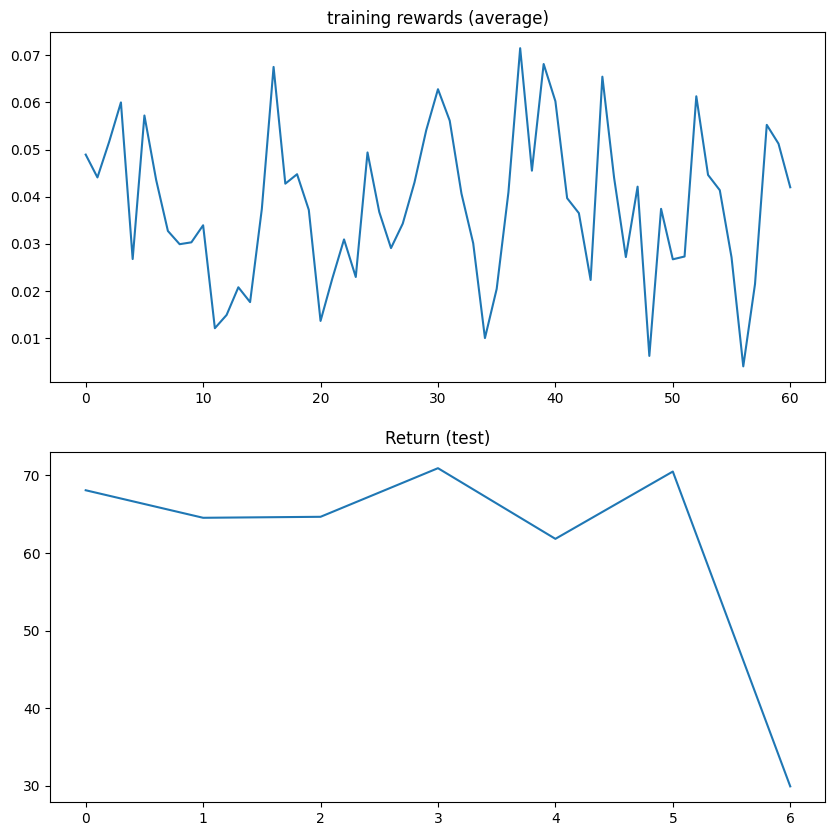

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.plot(logs["reward"])
plt.title("training rewards (average)")
plt.subplot(2, 1, 2)
plt.plot(logs["eval reward (sum)"])
plt.title("Return (test)")
plt.show()

In [ ]:
from torchrl.record import VideoRecorder
from torchrl.record.loggers.csv import CSVLogger

logger = CSVLogger(exp_name="final_agent", log_dir="videos", video_format="mp4")

recorded_env = TransformedEnv(
    GymEnv("NetHackScore-v0", device=device, categorical_action_encoding=True),
    Compose(
        ExcludeTransform("colors", "glyphs", "inv_glyphs", "inv_letters", "inv_oclasses", "inv_strs", "blstats", "message", "chars", "specials", "screen_descriptions"),
        DoubleToFloat(),
        render_tty_chars_transform,
        VideoRecorder(logger=logger, tag="run_video", skip=1, fps=1),
        BatchSizeTransform(reshape_fn=lambda x: x.unsqueeze(0)),
    ),
)

_ = recorded_env.rollout(500, policy_module)
#_ = recorded_env.rollout(100)
recorded_env.transform.dump()